<a href="https://colab.research.google.com/github/kopildas/project-103/blob/main/platelate_disorder_v6(StackingClassifier_%26_Lime).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
%load_ext cuml.accel
import sklearn

[2025-04-30 17:56:44.882] [CUML] [info] cuML: Installed accelerator for sklearn.
[2025-04-30 17:57:17.610] [CUML] [info] cuML: Installed accelerator for umap.
[2025-04-30 17:57:17.742] [CUML] [info] cuML: Installed accelerator for hdbscan.
[2025-04-30 17:57:17.743] [CUML] [info] cuML: Successfully initialized accelerator.


In [3]:
!pip install lime
!pip install scikeras
# !pip uninstall -y scikit-learn
!pip install scikit-learn==1.3.1
# !pip install -U scikit-learn
!pip install --upgrade xgboost

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 14.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=a85c40c87560e8327b7969cf03716e75a43931fdad6962f2c093ee504f38cf5e
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 111.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 106.4 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver d

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.9/253.9 MB 4.9 MB/s eta 0:00:00
  Attempting uninstall: xgboost
    Found existing installation: xgboost 2.1.4
    Uninstalling xgboost-2.1.4:
      Successfully uninstalled xgboost-2.1.4


In [1]:

import sklearn
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import ADASYN

**Data Cleaning and Reshaping**

In [2]:
# Loading the dataset
df = pd.read_excel("/content/drive/MyDrive/project_103/cbc_data.xlsx", sheet_name="cbc data", skiprows=1)

# Droping non-feature columns
df.drop(columns=['to_char', 'patient_name', 'gender_name', 'dob'], inplace=True)
# Ensure result values are numeric
df['result'] = pd.to_numeric(df['result'], errors='coerce')

In [3]:
# Pivoting to wide format (one row per prescription_ncid, one column per attribute_name)
pivot_df = df.pivot_table(index='prescription_ncid',
                          columns='attribute_name',
                          values='result',
                          aggfunc='first')
# Mergeing Hemoglobin/Haemoglobin columns if applicable
if 'Haemoglobin' in pivot_df.columns:
    pivot_df['Hemoglobin'] = pivot_df['Hemoglobin'].fillna(pivot_df['Haemoglobin'])
    pivot_df.drop(columns='Haemoglobin', inplace=True)

# Droping any rows without Platelet (cannot determine target for them)
pivot_df.dropna(subset=['Platelet'], inplace=True)



**Creating the Target Variable (Platelet_Disorder)**

In [ ]:
# Createing the Platelet_Disorder target column (0: low, 1: high, 2: normal)
pivot_df['Platelet_Disorder'] = 2
pivot_df.loc[pivot_df['Platelet'] < 150, 'Platelet_Disorder'] = 0
pivot_df.loc[pivot_df['Platelet'] > 450, 'Platelet_Disorder'] = 1

# Separateing features and target
pivot_df.reset_index(inplace=True)
X = pivot_df.drop(columns=['prescription_ncid', 'Platelet_Disorder'])
y = pivot_df['Platelet_Disorder']

# Split into training and test sets (stratified by class)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


**Handling Missing Values with KNN Imputation**

In [ ]:
# Impute missing values using KNN on training data and transform test data
imputer = KNNImputer(n_neighbors=5)
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed  = imputer.transform(X_test)


#Feature Scaling with Standardization
# Scale features (zero mean, unit variance) based on training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled  = scaler.transform(X_test_imputed)


#Balancing Classes with ADASYN Oversampling
# Oversample the training data using ADASYN to balance the classes
adasyn = ADASYN(random_state=42)
X_train_res, y_train_res = adasyn.fit_resample(X_train_scaled, y_train)

2nd step

In [ ]:
# Determine the number of classes (should be 3 in this case)
n_classes = len(np.unique(y_train))

**A Wrapper for Custom Models**

This wrapper thus bridges any gaps between third-party learners and scikit-learn’s ensemble tools, ensuring that stacking ensembles run smoothly and robustly

In [ ]:
from sklearn.base import BaseEstimator, ClassifierMixin

class ProbaWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, model):
        self.model = model

    def fit(self, X, y):
        self.model.fit(X, y)
        return self

    def predict(self, X):
        return self.model.predict(X)

    def predict_proba(self, X):
        return self.model.predict_proba(X)

In [ ]:
# Defining a simple neural network model for KerasClassifier
from scikeras.wrappers import KerasClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


import random, tensorflow as tf
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)


In [ ]:
from tensorflow.keras.layers import Input

def create_nn_model():
    model = Sequential()
    model.add(Input(shape=(X_train_res.shape[1],)))  # Explicit input layer
    model.add(Dense(32, activation='relu'))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(n_classes, activation='softmax'))
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model



In [ ]:
# Initialize base classifiers
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# Initialize base classifiers with corrected parameters
rf = RandomForestClassifier(n_estimators=100, random_state=42)
gb = GradientBoostingClassifier(random_state=42)
xgb = XGBClassifier(eval_metric='mlogloss', random_state=42)
nn_raw = KerasClassifier(
    model=create_nn_model,
    epochs=50,
    batch_size=32,
    verbose=0,
    # Add these parameters to ensure sklearn compatibility
    optimizer='adam',
    loss='sparse_categorical_crossentropy'
)
nn = ProbaWrapper(nn_raw)

In [ ]:
# Wraping certain models with calibration for better probability estimates
from sklearn.calibration import CalibratedClassifierCV
rf_calib = CalibratedClassifierCV(rf, cv=5, method='sigmoid')   # calibrate RandomForest
gb_calib = CalibratedClassifierCV(gb, cv=5, method='sigmoid')   # calibrate GradientBoosting

# Building stacking ensemble with the base models
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.calibration import CalibratedClassifierCV

In [ ]:
def ensure_proba(estimator):
    if not hasattr(estimator, "predict_proba"):
        # Wraping in a 3-fold calibrator by default
        return CalibratedClassifierCV(estimator, cv=3, method='sigmoid')
    return estimator


base_estimators = [
    ('rf',  rf_calib),
    ('xgb', xgb),
    ('gb',  gb_calib),
    ('nn',  nn_raw)
]


wrapped_estimators = [(name, ensure_proba(est)) for name, est in base_estimators]

stack_model = StackingClassifier(
    estimators=wrapped_estimators,
    final_estimator=LogisticRegression(),
    stack_method='predict_proba',
    cv=5,
)
# Training the stacking ensemble on the resampled training data
stack_model.fit(X_train_res, y_train_res)

StackingClassifier(cv=5,
                   estimators=[('rf',
                                CalibratedClassifierCV(cv=5,
                                                       estimator=RandomForestClassifier(random_state=42))),
                               ('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric='mlogloss',
                                              feature_t...
                                              n_estimators=None, n_jobs=None,
                                              num_parallel_tree=None, ...)),
                               ('gb',
                                CalibratedClassifierCV(cv=5,
                                                       estimator=GradientBoostingClassifier(random_state=42))),
                               ('nn',
                                KerasClassifier(batch_size=32, epochs=50, loss='sparse_categorical_crossentropy', model=<function create_nn_model at 0x7e5fdebd3240>, optimizer='adam', verbose=0))],
                   final_estimator=LogisticRegression(),
                   stack_method='predict_proba')

**Model EVALUATION:**

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, auc
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Assuming y contains your target variable (e.g., y_train or y)
le = LabelEncoder()
le.fit(y)



# Predict on the test set
y_pred = stack_model.predict(X_test_scaled)
y_proba = stack_model.predict_proba(X_test_scaled)

Confusion Matrix:
 [[  9   0   0]
 [  0  10   0]
 [  0   0 110]]


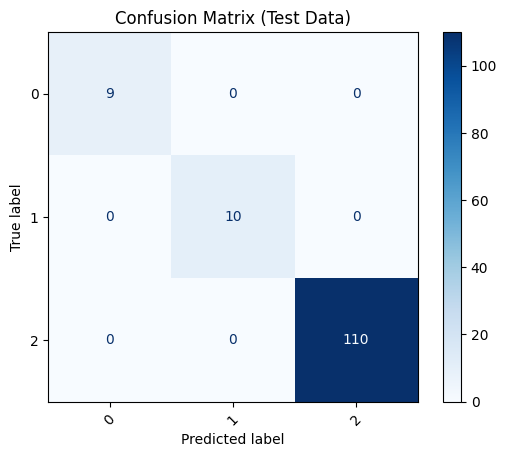

In [ ]:
# Evaluating performance with confusion matrix and classification report
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix (Test Data)")
plt.show()

In [ ]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_.astype(str)))
# Computing ROC curves and AUC for each class
y_test_bin = np.zeros((y_test.shape[0], n_classes))
y_test_bin[np.arange(y_test.shape[0]), y_test] = 1  # one-hot encode y_test
y_proba = np.array(y_proba)

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00       110

    accuracy                           1.00       129
   macro avg       1.00      1.00      1.00       129
weighted avg       1.00      1.00      1.00       129



In [ ]:
fpr = {}; tpr = {}; roc_auc = {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
# Compute micro-average ROC curve and AUC
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_proba.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
# Compute macro-average ROC curve and AUC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

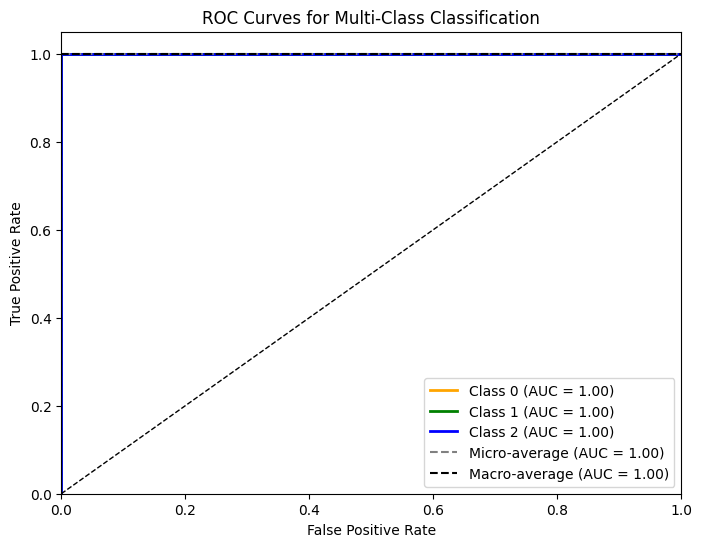

In [ ]:
# Ploting ROC curves for each class
plt.figure(figsize=(8,6))
colors = ['orange', 'green', 'blue']
for i, color in enumerate(colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f"Class {le.classes_[i]} (AUC = {roc_auc[i]:.2f})")
# Ploting micro-average and macro-average ROC
plt.plot(fpr["micro"], tpr["micro"], linestyle='--', color='gray',
         label=f"Micro-average (AUC = {roc_auc['micro']:.2f})")
plt.plot(fpr["macro"], tpr["macro"], linestyle='--', color='black',
         label=f"Macro-average (AUC = {roc_auc['macro']:.2f})")
# Ploting diagonal line for random guess
plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Multi-Class Classification")
plt.legend(loc="lower right")
plt.show()

**Model Interpretability with LIME**

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

In [ ]:

pipeline = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),               # handle NaNs :contentReference[oaicite:0]{index=0}
    ('scaler',  StandardScaler()),                         # zero-mean/unit-variance :contentReference[oaicite:1]{index=1}
    ('stack',   stack_model)                               # ensemble meta-model :contentReference[oaicite:2]{index=2}
])
# Fit on resampled training data
pipeline.fit(X_train.values, y_train)

Pipeline(steps=[('imputer', KNNImputer()), ('scaler', StandardScaler()),
                ('stack',
                 StackingClassifier(cv=5,
                                    estimators=[('rf',
                                                 CalibratedClassifierCV(cv=5,
                                                                        estimator=RandomForestClassifier(random_state=42))),
                                                ('xgb',
                                                 XGBClassifier(base_score=None,
                                                               booster=None,
                                                               callbacks=None,
                                                               colsample_bylevel=None,
                                                               colsample_bynode=None,
                                                               colsample_bytree=None,
                                                               device=None,
                                                               early_...
                                                               num_parallel_tree=None, ...)),
                                                ('gb',
                                                 CalibratedClassifierCV(cv=5,
                                                                        estimator=GradientBoostingClassifier(random_state=42))),
                                                ('nn',
                                                 KerasClassifier(batch_size=32, epochs=50, loss='sparse_categorical_crossentropy', model=<function create_nn_model at 0x7c52ca51dbc0>, optimizer='adam', verbose=0))],
                                    final_estimator=LogisticRegression(),
                                    stack_method='predict_proba'))])

In [ ]:
# Evaluating on hold-out set without extra preprocessing
y_pred  = pipeline.predict(X_test)        # does impute+scale before predicting :contentReference[oaicite:5]{index=5}
y_proba = pipeline.predict_proba(X_test)  # directly yields probabilities

from lime.lime_tabular import LimeTabularExplainer

# Impute the training data (pipeline was already fit)
X_train_imp = pipeline.named_steps['imputer'].transform(X_train.values)

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:458: UserWarning: X has feature names, but KNNImputer was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:458: UserWarning: X has feature names, but KNNImputer was fitted without feature names
  warnings.warn(


In [ ]:
# Build LIME explainer around your raw (unscaled, un-imputed) feature matrix
explainer = LimeTabularExplainer(
    # training_data   = X_train.values,
    # feature_names   = X_train.columns.tolist(),
    # class_names     = [str(c) for c in le.classes_],
    training_data=X_train_imp,
    feature_names=list(X_train.columns),
    class_names     = [str(c) for c in le.classes_],
    mode            = 'classification',
    discretize_continuous=True,
    random_state    = 42
)


In [ ]:
# Pick a raw test sample
idx    = 0
raw_x  = X_test.iloc[idx].values      # raw features with NaNs allowed
true_y = y_test.iloc[idx]

# Explain via the pipeline’s predict_proba
exp = explainer.explain_instance(
    raw_x,
    pipeline.predict_proba,   # LIME will impute & scale internally :contentReference[oaicite:7]{index=7}
    num_features=5,
    labels=[int(true_y)]
)

# Display the top 5 feature contributions
for feat, weight in exp.as_list(label=int(true_y)):
    print(f"{feat}: {weight:.3f}")

Platelet <= 237.75: -0.253
3.30 < Eosinophils (%) <= 5.83: 0.028
12.10 < Hemoglobin <= 13.10: -0.022
0.30 < Basophils (%) <= 0.40: -0.017
78.80 < MCV <= 82.80: -0.015


In [ ]:
# Explaining a test instance (with NaNs). Let pipeline handle imputation.
test_row = X_test.iloc[0].values  # may contain NaNs
exp = explainer.explain_instance(test_row, pipeline.predict_proba, num_features=5)
exp.as_list()

[('Platelet <= 237.75', -0.1666631648062109),
 ('IG% > 0.36', -0.020236277297170806),
 ('4.51 < RBC <= 4.94', -0.019292998275565677),
 ('78.80 < MCV <= 82.80', 0.019170446648462167),
 ('37.30 < PCV/HCT <= 40.30', -0.01803954923046784)]

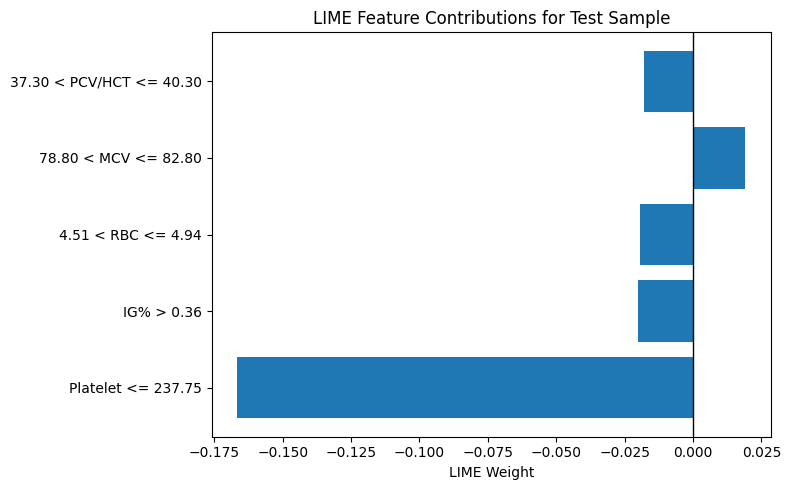

In [ ]:
# Pulling out the top-5 feature–weight tuples
labels_explained = exp.available_labels()         # e.g. [2, 0, 1]
label_to_plot = labels_explained[0]               # pick the highest-probability class

# 3. Extracting the (feature, weight) list
feat_weights = exp.as_list(label=label_to_plot)
features, weights = zip(*feat_weights)

# 2. Ploting inline in Colab
%matplotlib inline
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.barh(features, weights)
plt.axvline(0, color='black', linewidth=1)
plt.xlabel('LIME Weight')
plt.title('LIME Feature Contributions for Test Sample')
plt.tight_layout()
plt.show()